In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Downloads123\NCUA_Auto_Loan_Data\auto_loans_final.csv")
print(df.columns.tolist())
print(df.dtypes)
print(df.head())
print(df['CYCLE_DATE'].unique())

['CU_NUMBER', 'CYCLE_DATE', 'ACCT_021C', 'ACCT_021D', 'ACCT_020C1', 'ACCT_020C2']
CU_NUMBER      int64
CYCLE_DATE    object
ACCT_021C      int64
ACCT_021D      int64
ACCT_020C1     int64
ACCT_020C2     int64
dtype: object
   CU_NUMBER CYCLE_DATE  ACCT_021C  ACCT_021D  ACCT_020C1  ACCT_020C2
0          1    2024-03          0          0       44395       39902
1          6    2024-03          0          0      331491     1423742
2         12    2024-03          0          0       38928       21390
3         13    2024-03          0          0     4812056     5497039
4         16    2024-03          0          0           0           0
['2024-03' '2024-06' '2024-09' '2024-12' '2025-03' '2025-06' '2025-09'
 '2025-12']


In [2]:
df['total_delinq'] = df['ACCT_021C'] + df['ACCT_021D']
df['total_auto']   = df['ACCT_020C1'] + df['ACCT_020C2']

quarterly = df.groupby('CYCLE_DATE')[['total_delinq', 'total_auto']].sum()
quarterly['delinq_rate'] = quarterly['total_delinq'] / quarterly['total_auto']

print(quarterly)

            total_delinq  total_auto  delinq_rate
CYCLE_DATE                                       
2024-03          9749816  6507553209     0.001498
2024-06          9712714  6873554588     0.001413
2024-09         10584477  6989422358     0.001514
2024-12         10330106  7818046864     0.001321
2025-03          8063377  6693818042     0.001205
2025-06          8077610  6693075453     0.001207
2025-09          9427408  6846676623     0.001377
2025-12          9366157  7796273480     0.001201


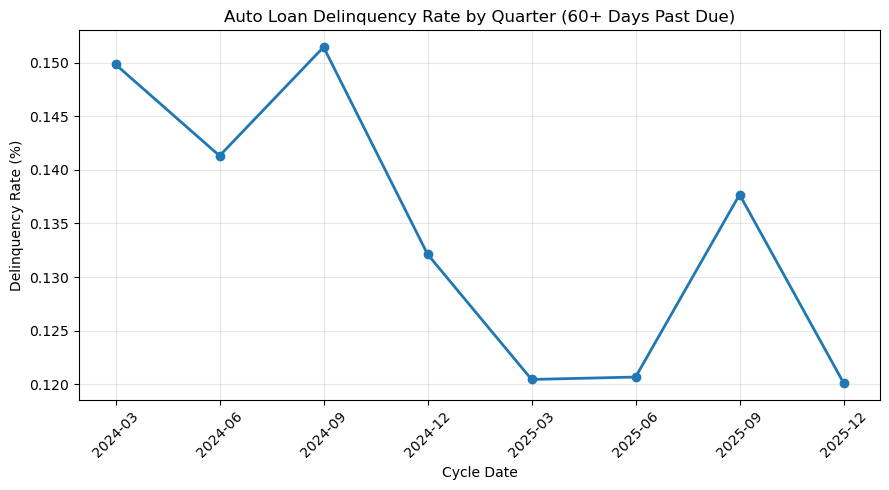

In [3]:
import matplotlib.pyplot as plt

quarterly['delinq_rate_pct'] = quarterly['delinq_rate'] * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(quarterly.index, quarterly['delinq_rate_pct'], marker='o', linewidth=2)
ax.set_title('Auto Loan Delinquency Rate by Quarter (60+ Days Past Due)')
ax.set_ylabel('Delinquency Rate (%)')
ax.set_xlabel('Cycle Date')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('delinquency_trend.png', dpi=150)
plt.show()